<a href="https://colab.research.google.com/github/joyangelai/Colabs/blob/main/cohort2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Exploratory Data  Analysis(EDA)

In [ ]:
#import depedency libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#get the sns dataset names
print(sns.get_dataset_names(), end=" ")

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic'] 

In [ ]:
#get tips dataset from seaborn
df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
#checking the shape
print(f" This dataset contains {df.shape[0]} records and {df.shape[1]} columns")

 This dataset contains 244 records and 7 columns


In [ ]:
#concise stat summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


## Data cleaning


In [ ]:
#check unique values
for coln in df:
    un_value = df[coln].unique()
    print(f" {coln}, {un_value}", "\n")


 total_bill, [16.99 10.34 21.01 23.68 24.59 25.29  8.77 26.88 15.04 14.78 10.27 35.26
 15.42 18.43 14.83 21.58 10.33 16.29 16.97 20.65 17.92 20.29 15.77 39.42
 19.82 17.81 13.37 12.69 21.7  19.65  9.55 18.35 15.06 20.69 17.78 24.06
 16.31 16.93 18.69 31.27 16.04 17.46 13.94  9.68 30.4  18.29 22.23 32.4
 28.55 18.04 12.54 10.29 34.81  9.94 25.56 19.49 38.01 26.41 11.24 48.27
 13.81 11.02 17.59 20.08 16.45  3.07 20.23 15.01 12.02 17.07 26.86 25.28
 14.73 10.51 27.2  22.76 17.29 19.44 16.66 10.07 32.68 15.98 34.83 13.03
 18.28 24.71 21.16 28.97 22.49  5.75 16.32 22.75 40.17 27.28 12.03 12.46
 11.35 15.38 44.3  22.42 20.92 15.36 20.49 25.21 18.24 14.31 14.    7.25
 38.07 23.95 25.71 17.31 29.93 10.65 12.43 24.08 11.69 13.42 14.26 15.95
 12.48 29.8   8.52 14.52 11.38 22.82 19.08 20.27 11.17 12.26 18.26  8.51
 14.15 16.   13.16 17.47 34.3  41.19 27.05 16.43  8.35 18.64 11.87  9.78
  7.51 14.07 13.13 17.26 24.55 19.77 29.85 48.17 25.   13.39 16.49 21.5
 12.66 16.21 17.51 24.52 20.76 31.71 10.

In [ ]:
#null values.. using isna/ isnull()
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [ ]:
#duplicates. using duplicated()
df.duplicated().sum()

1

In [ ]:
#solving duplicates
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

### 1. Univariate Data Analaysis

This deals with one variable only.

In [ ]:
#check cloumns
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

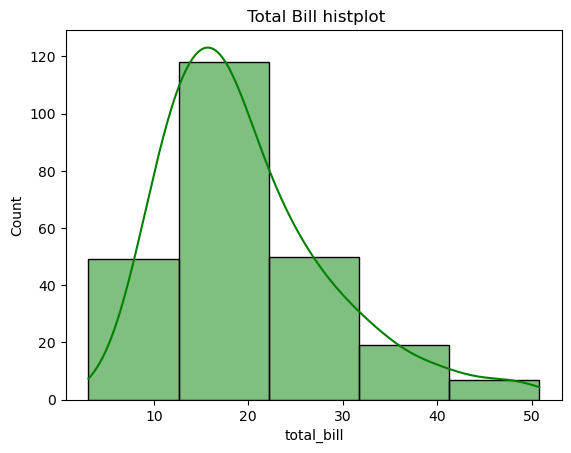

In [ ]:
# total_bill univariate analsys
sns.histplot(df["total_bill"], bins=5, color="g", kde=True)
plt.title(" Total Bill histplot");

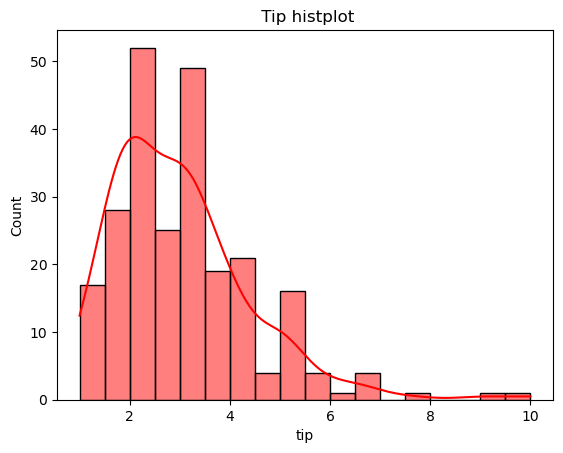

In [ ]:
#Tips
sns.histplot(df["tip"], color="r", kde=True)
plt.title(" Tip histplot");

Obervation: majority of the tips was between 2 to 3 dollars

<Axes: xlabel='sex'>

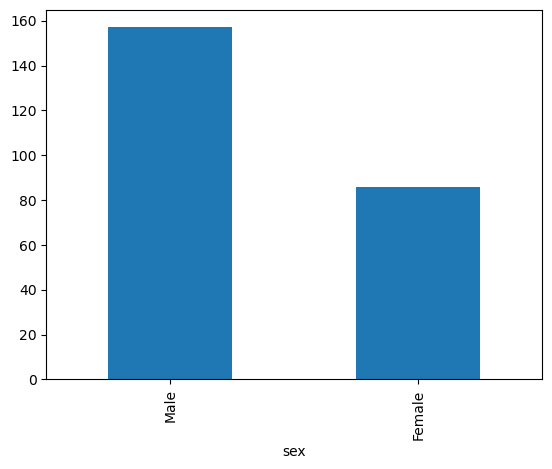

In [ ]:
# Gender analsys
#figure =figsize=(2,8))
sex_count = df["sex"].value_counts()
sex_count.plot(kind="bar")

<Axes: xlabel='sex', ylabel='count'>

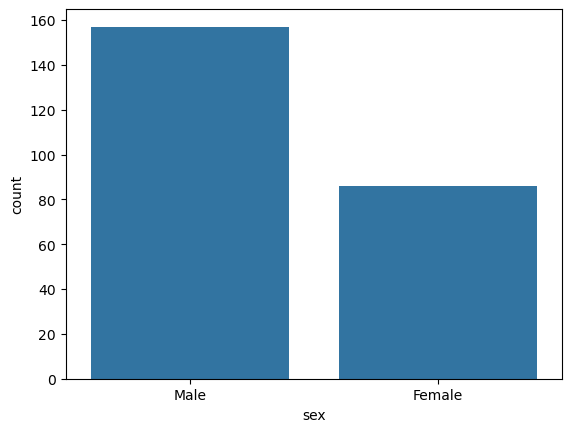

In [ ]:
sns.barplot(sex_count)

<Axes: xlabel='smoker', ylabel='count'>

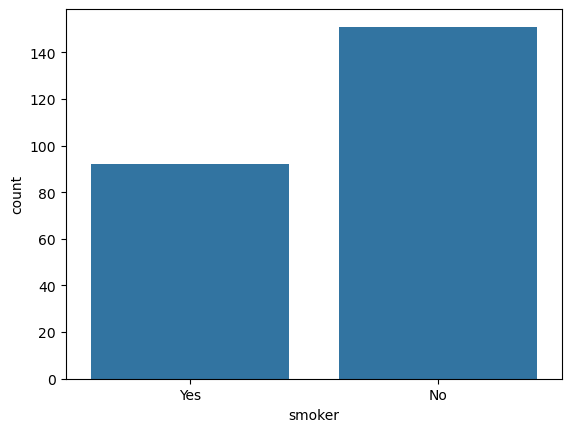

In [ ]:
sns.barplot(df["smoker"].value_counts())

<Axes: xlabel='smoker'>

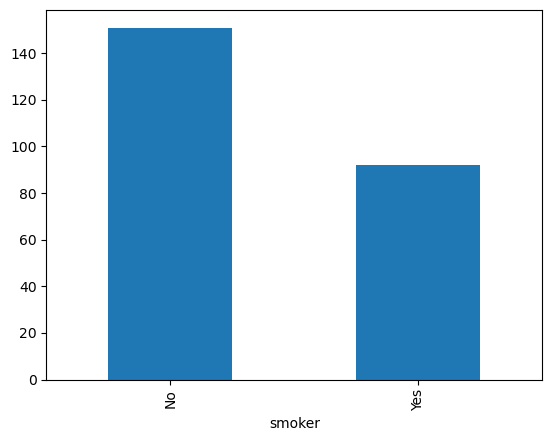

In [ ]:
#using matplotlib
df["smoker"].value_counts().plot(kind="bar")

In [ ]:
#try visualizing time using piechart

### 2. BIvariate analtysis
used to check the r/ship or association between variables( 2 variables)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8660\805611838.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex_gr = df.groupby(["sex"])["tip"].sum()


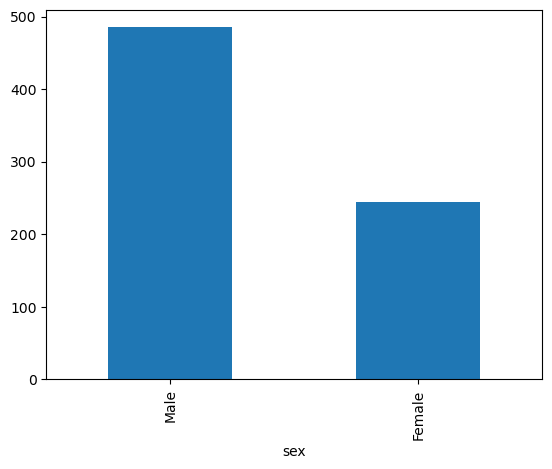

In [ ]:
#r/ship btn tip and sex

sex_gr = df.groupby(["sex"])["tip"].sum()
sex_gr.plot(kind="bar");

<Axes: xlabel='sex', ylabel='tip'>

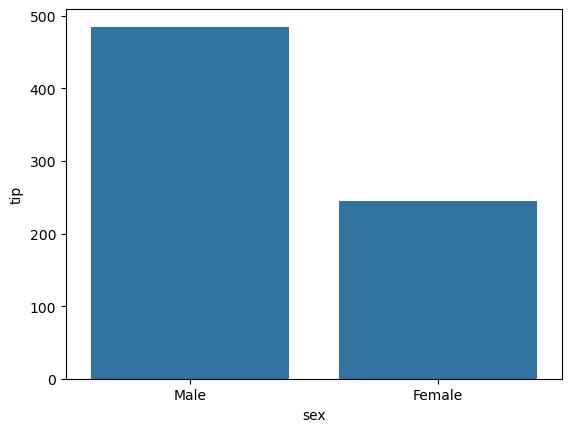

In [ ]:
sns.barplot(sex_gr)

<Axes: xlabel='total_bill', ylabel='tip'>

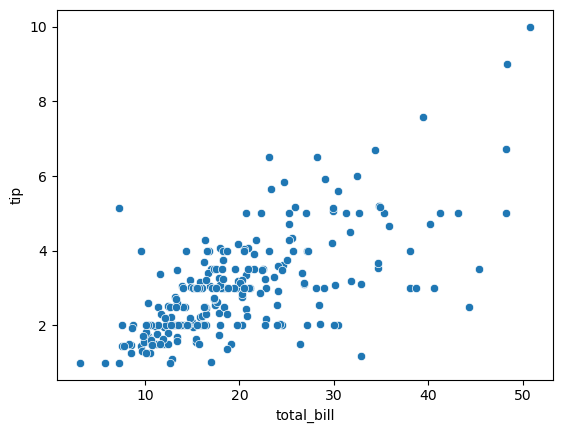

In [ ]:
# analays on total_bll vs tips

sns.scatterplot(x = "total_bill", y="tip", data=df)

In [ ]:
cat_r = pd.crosstab(df["sex"], df["smoker"])
cat_r

smoker,Yes,No
sex,,
Male,60,97
Female,32,54


<Axes: xlabel='sex'>

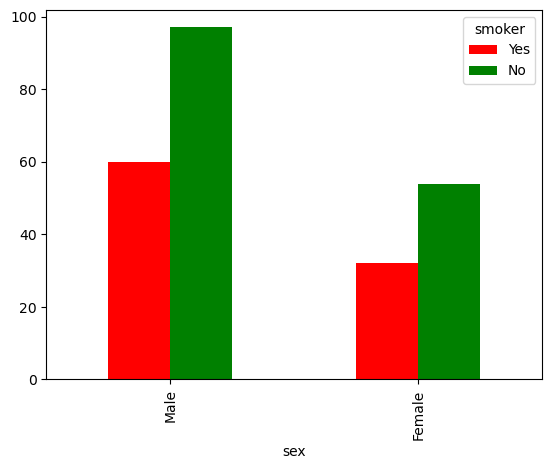

In [ ]:
cat_r.plot(kind="bar", color= ["r", "g"])

<Axes: ylabel='total_bill'>

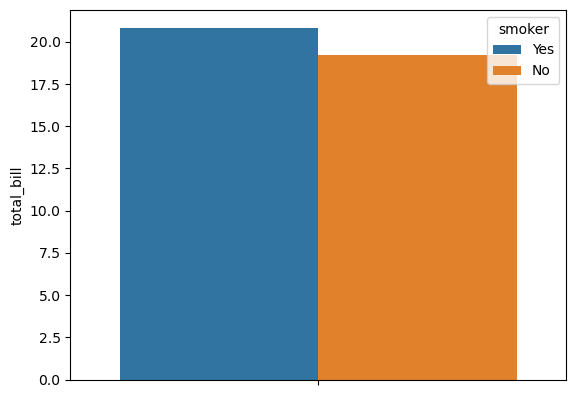

In [ ]:
sns.barplot(y= df["total_bill"], hue = df["smoker"] , errorbar=None)

In [ ]:
#heatmap
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
corr_df = df[["total_bill", "tip", "size"]]
corr_df.head()

,total_bill,tip,size
0,16.99,1.01,2
1,10.34,1.66,3
2,21.01,3.50,3
3,23.68,3.31,2
4,24.59,3.61,4


In [ ]:
#get corr
corr =corr_df.corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.674998,0.597589
tip,0.674998,1.000000,0.488400
size,0.597589,0.488400,1.000000


In [ ]:
#how to get colr themes for heatmap
print(plt.colormaps(), end=" ")

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', '

<Axes: >

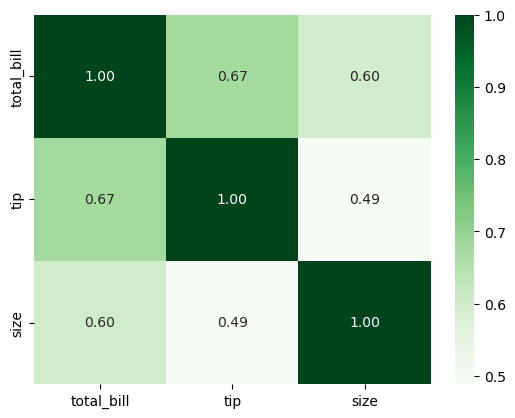

In [ ]:
#heatmap
sns.heatmap(corr, annot=True, fmt="1.2f", cmap="Greens")

### 3. Multivariate analysis
this deals with more than 3 variables

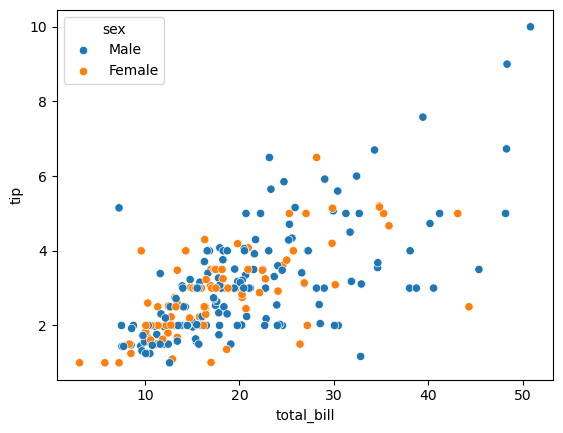

In [ ]:
#r/ship btn tip, totalbill and gender
sns.scatterplot(x= "total_bill", y="tip", hue = "sex" , data=df, );

<Axes: xlabel='total_bill', ylabel='tip'>

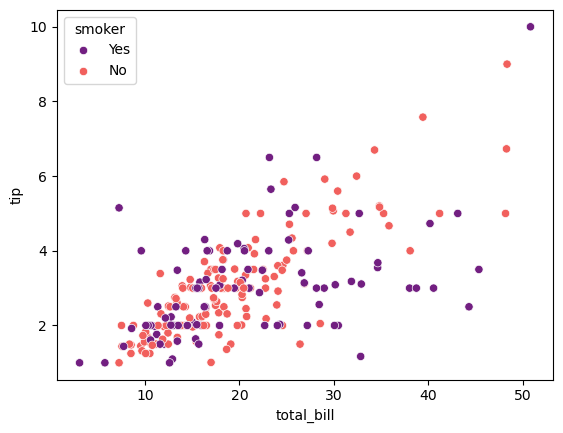

In [ ]:
#r/ship btn tip, totalbill and smoker
sns.scatterplot(x= "total_bill", y="tip", hue = "smoker" , data=df, palette= "magma")

C:\Users\DELL\AppData\Local\Temp\ipykernel_8660\1339466416.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp4 = df.groupby(["sex"])[["total_bill", "tip"]].sum()


TypeError: matplotlib.font_manager.FontProperties() argument after ** must be a mapping, not int

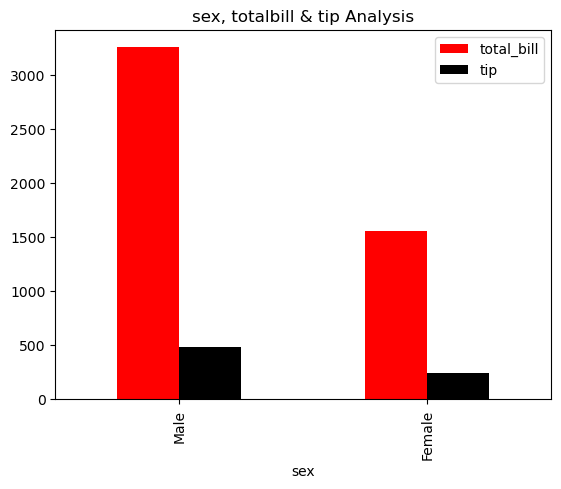

In [ ]:
#using matplotlib to display the above
#r/ship btn tip, totalbill and gender
grp4 = df.groupby(["sex"])[["total_bill", "tip"]].sum()
grp4.plot(kind="bar", color= ["r", "k"])
plt.title("sex, totalbill & tip Analysis", font=(10))
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8660\2943631120.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp4 = df.groupby(["smoker"])[["total_bill", "tip"]].sum()


<Axes: xlabel='smoker'>

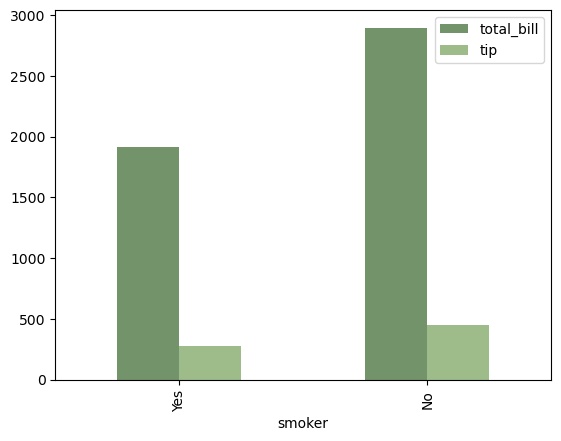

In [ ]:
#r/ship among smoker, total bill and tip
grp4 = df.groupby(["smoker"])[["total_bill", "tip"]].sum()
grp4.plot(kind="bar", color =["#73946B", "#9EBC8A"])

## Feature enginearing

This is the act of creating more columns or combining columns from already existing ones


In [ ]:
df.head(4)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2


In [ ]:
#create profit column
df["profit"] = df["total_bill"] + df["tip"]

df.head()

,total_bill,tip,sex,smoker,day,time,size,profit
0,16.99,1.01,Female,No,Sun,Dinner,2,18.00
1,10.34,1.66,Male,No,Sun,Dinner,3,12.00
2,21.01,3.50,Male,No,Sun,Dinner,3,24.51
3,23.68,3.31,Male,No,Sun,Dinner,2,26.99
4,24.59,3.61,Female,No,Sun,Dinner,4,28.20


In [ ]:
#create tax column
df['tax'] = df["total_bill"]*0.02

df.head()

,total_bill,tip,sex,smoker,day,time,size,profit,tax
0,16.99,1.01,Female,No,Sun,Dinner,2,18.00,0.3398
1,10.34,1.66,Male,No,Sun,Dinner,3,12.00,0.2068
2,21.01,3.50,Male,No,Sun,Dinner,3,24.51,0.4202
3,23.68,3.31,Male,No,Sun,Dinner,2,26.99,0.4736
4,24.59,3.61,Female,No,Sun,Dinner,4,28.20,0.4918


# Extra learning

In [ ]:
taxi = sns.load_dataset("taxis")
taxi.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
taxi.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [ ]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
taxi['pickup'] = taxi["pickup"].astype("object")

In [ ]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   object        
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(

In [ ]:
#coverting date to datetime
taxi['pickup'] =pd.to_datetime(taxi["pickup"])

In [ ]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
#assignemt. try to rectreate columns from pickup variable like month, year, time